Iter  m0              m1              mk              f(mk)                f'(mk)               ea             
1     30.0000000000   40.0000000000   57.2614637830   -1.2785891596        0.4815861310         30.1449921860  
2     40.0000000000   57.2614637830   59.6665196993   -0.1367642242        0.4679748477         4.0308298999   
3     57.2614637830   59.6665196993   59.9545897846   -0.0021871515        0.4663614219         0.4804804542   
4     59.6665196993   59.9545897846   59.9592715102   -0.0000038366        0.4663352321         0.0078081763   
5     59.9545897846   59.9592715102   59.9592797372   -0.0000000001        0.4663351861         0.0000137209   

The root is 59.9592797372 (Approx.)


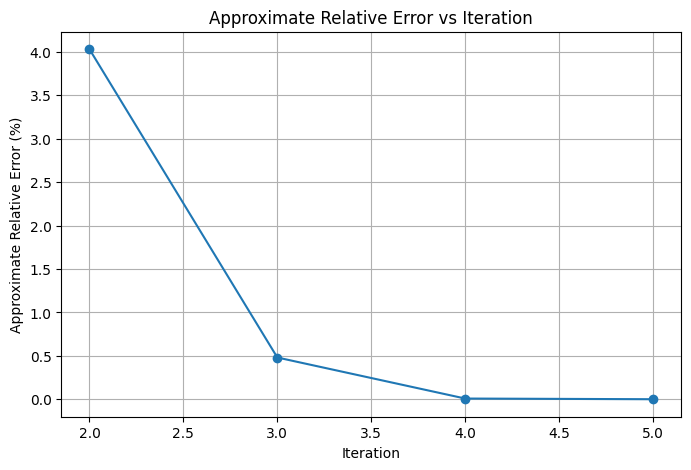

In [1]:
#Secant method of finding roots
import numpy as np
import matplotlib.pyplot as plt
import math as m

#Secant function
def sec(x):
  g = 9.81
  y = 36
  c = 15
  t = 10
  A = (g * x) / c
  B = 1 - m.exp(-(c/x) * t)
  result = A * B - y
  return result

def sec_der(x):
  g = 9.81
  c = 15
  t = 10
  B = m.exp(-(c/x) * t)
  result = (g / c) * (1 - B - (c*t / x) * B)
  return result

#Given data
es = 0.001
ea = 100
i = 0
m0 = 30
m1 = 40

#Plotting Criterion
iterations = []
approx_errors = []

#Root checking logic
print(f"{'Iter':<5} {'m0':<15} {'m1':<15} {'mk':<15} {'f(mk)':<20} {'f\'(mk)':<20} {'ea':<15}")
while ea > es:
  i += 1
  mk = m1 - sec(m1) * ((m1 - m0) / (sec(m1) - sec(m0)))

  ea = abs((mk - m1)/mk) * 100
  print(f"{i:<5} {m0:<15.10f} {m1:<15.10f} {mk:<15.10f} {sec(mk):<20.10f} {sec_der(mk):<20.10f} {ea:<15.10f}")

  if (i > 1):
    iterations.append(i)
    approx_errors.append(ea)

  m0 = m1
  m1 = mk

print(f"\nThe root is {mk:.10f} (Approx.)")

#Graph Plot
plt.figure(figsize=(8,5))
plt.plot(iterations, approx_errors, marker='o')
plt.title('Approximate Relative Error vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('Approximate Relative Error (%)')
plt.grid(True)
plt.show()